<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/project_euler_eq_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [ ]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [ ]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and for a perfect gas, the pressure is given by

$p = (\gamma - 1)(E-\frac{\vert u\vert^2}{2}),$

where $\gamma = 1.4$ is the specific heat ratio for air, and we get the temperature,

$T = \frac{E}{\rho} - \frac{\vert u\vert^2}{2},$

the speed of sound,

$\sqrt{\gamma(\gamma-1)T},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

# **Method**

**Define domain and mesh**

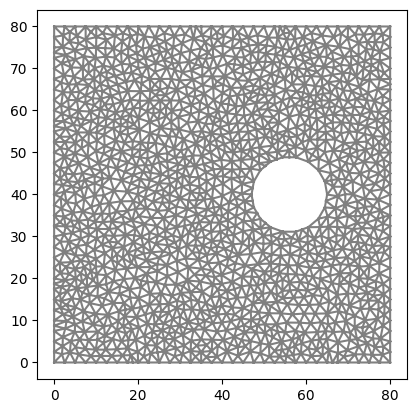

In [ ]:
# Define rectangular domain
L = 80.0
H = 80.0

# Define circle
xc = 0.7*L
yc = 0.5*H
rc = 9

# Specific heat ratio for air
gamma = 1.4

# Generate mesh (examples with and without a hole in the mesh)
resolution = 32
#mesh = RectangleMesh(Point(0.0, 0.0), Point(L, H), L*resolution, H*resolution)
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(xc,yc),rc), resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(xc, yc)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

class Object(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

left = Left()
right = Right()
lower = Lower()
upper = Upper()
object = Object()

# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)
object.mark(boundaries, 5)

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

plt.figure()
plot(mesh)
plt.show()

### Defining the meteor

In [ ]:

# Material density in kg/m³ (representing meteor compositions)
materials = {
    "iron": 7870.0,                      # iron meteor
    "ice": 917.0,                        # pure ice
    "stone": 3500.0,                     # rocky meteor
    "mixed": 0.6 * 7870.0 + 0.4 * 917.0  # 60% iron, 40% ice
}

# Select composition
material_choice = "iron"
object_density = materials[material_choice]

# Assumed depth of the 3D object (m)
object_depth = 1.0

# Compute area of the circular object (2D projection)
object_area = np.pi * rc**2  # m²

# Compute volume and mass
object_volume = object_area * object_depth  # m³
mass_object = object_density * object_volume  # kg

print(f"Material: {material_choice}, Mass: {mass_object/1000:.2f} tons")



Material: iron, Mass: 2002.67 tons


**Define finite element approximation spaces**

In [ ]:
# Generate finite element spaces (for density, momentum, total energy)
R = FunctionSpace(mesh, "Lagrange", 1)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
r = TrialFunction(R)
m = TrialFunction(V)
E = TrialFunction(Q)
d = TestFunction(R)
v = TestFunction(V)
q = TestFunction(Q)

### Inflow Functions: Altitude-Dependent

The inflow boundary conditions are derived from empirical models based on the U.S. Standard Atmosphere 1976. Data was collected for altitudes up to 85 km and extrapolated beyond, **assuming** the underlying physical trends remain valid.

Let $h$ denote the altitude in meters.

---

#### Temperature (K)

The temperature as a function of altitude is approximated using a cubic polynomial fit:

$$
T_{fit}(h) = -0.0016 \left( \frac{h}{1000} \right)^3 + 0.1905 \left( \frac{h}{1000} \right)^2 - 5.9628 \left( \frac{h}{1000} \right) + 277.3354
$$

As one can see this model encounters problems as high altitudes. Therefore the following modified simplistic function will be used:

$$
  T(h) = \max(T_{fit}(h), 1)
$$
---

#### Density (kg/m³)

The atmospheric density is modeled using an exponential decay:
$$
\rho(h) = 1.228 \cdot \exp\left( -0.1168 \cdot \frac{h}{1000} \right)
$$

---

#### Velocity Update (Newton's Second Law)

The inflow velocity evolves dynamically according to Newton's second law:
$$
a(t) = \frac{F_{\text{net}}(t)}{m} = \frac{mg - D(t)}{m}
$$

where:
- $m$ is the mass of the falling object,
- $g = 9.81 \, \mathrm{m/s^2}$ is the gravitational acceleration,
- $D(t)$ is the drag force obtained from the simulation.

The velocity is then updated at each time step $\Delta t$ as:
$$
v(t + \Delta t) = v(t) + a(t) \cdot \Delta t
$$

This updated velocity is used to compute the inflow momentum and energy:
$$
m_{\text{in}} = \rho(h) \cdot v(t), \quad E_{\text{in}} = E(h, v(t))
$$

---

#### Total Energy (J/kg)

The total energy at the inflow boundary is computed as:
$$
E(h, v) = \rho(h) \cdot \left( \frac{1}{2} v^2 + \frac{R \cdot T(h)}{\gamma - 1} \right)
$$

where:
- $R = 287.05 \, \mathrm{J/(kg{\cdot}K)}$ is the specific gas constant for dry air,
- $\gamma = 1.4$ is the ratio of specific heats for air,
- $v$ is the current inflow velocity.

---

All inflow quantities are updated dynamically during the simulation based on the current altitude and velocity.


In [ ]:
def inflow_density(h):
    h_km = h / 1000
    rho_min = 1.0e-6
    return max(1.228 * np.exp(-0.1168 * h_km), rho_min)

def inflow_temperature(h):
    # h is in meters, convert to km
    # Fitted model using Matlab and Wikipedia values for standard Atmosphere
    h_km = h / 1000
    return max(-0.0016 * h_km**3 + 0.1905 * h_km**2 - 5.9628 * h_km + 277.3354, 1)


def inflow_energy(altitude, velocity):      # Dependent on inflow velo. and altitude
    rho = inflow_density(altitude)
    T = inflow_temperature(altitude)
    return rho * (0.5 * velocity**2 + 287.05 * T / (gamma - 1))


**Define boundary conditions**

In [ ]:
# Boundary identifiers
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary, H=H):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary, L=L):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

# Inflow variables as FEniCS Constants (modifiable in time loop)
m_in_val = Constant(4.0)
r_in_val = Constant(1.4)
E_in_val = Constant(8.94)
m_in_vec = as_vector([m_in_val, 0.0])

# Momentum boundary conditions
bcm_in0 = DirichletBC(V.sub(0), m_in_val, dbc_left)
bcm_in1 = DirichletBC(V.sub(1), Constant(0.0), dbc_left)
bcm_upp0 = DirichletBC(V.sub(0), Constant(0.0), dbc_upper)
bcm_upp1 = DirichletBC(V.sub(1), Constant(0.0), dbc_upper)
bcm_low0 = DirichletBC(V.sub(0), Constant(0.0), dbc_lower)
bcm_low1 = DirichletBC(V.sub(1), Constant(0.0), dbc_lower)

# Mass and energy inflow boundary conditions
bcr_in = DirichletBC(R, r_in_val, dbc_left)
bcE_in = DirichletBC(Q, E_in_val, dbc_left)

bcm = [bcm_in0, bcm_in1, bcm_upp1, bcm_low1]
bcr = [bcr_in]
bcE = [bcE_in]


# **Results**

**Define method parameters**

In [ ]:
# Define iteration functions
# *0 solution from previous time step
r0 = Function(R)
m0 = Function(V)
E0 = Function(Q)
r1 = Function(R)
m1 = Function(V)
E1 = Function(Q)

eps_cav = 1.0e-6

# Set parameters for nonlinear and linear solvers
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step: set initial guess, will be updated later
dt = Constant(0.5 * mesh.hmin() * float(r_in_val) / float(m_in_val))


**Define variational problem**

In [ ]:
# Mean velocities for trapezoidal time stepping
rm = 0.5*(r + r0)
mm = 0.5*(m + m0)
Em = 0.5*(E + E0)

rm1 = 0.5*(r1 + r0)
mm1 = 0.5*(m1 + m0)
Em1 = 0.5*(E1 + E0)

u0 = m0 / (r0 + eps_cav)
u1 = m1 / (r1 + eps_cav)
um1 = 0.5*(u1 + u0)

# Perfect gas
p1 = (gamma - 1.0) * (E1 - 0.5 * inner(m1, m1) / (r1 + eps_cav))

# Temperature and speed of sound
Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)
c = sqrt(gamma * (gamma - 1.0) * Temp)

# Mach number
Mach = sqrt(inner(u1, u1)) / c

# Facet normal and cell size
normal = FacetNormal(mesh)
h = CellDiameter(mesh)

# Stabilization and penalty
u_mag = sqrt(dot(u1, u1))
C1 = 1.0
d1 = C1 / sqrt((pow(1.0/dt, 2.0) + pow(u_mag / h, 2.0)))
C_alpha = 1.0e2
alpha = C_alpha / h

# Residuals
res_r = (r1 - r0) / dt + div(u1) * r1 + inner(grad(r1), u1)
res_m = (m1 - m0) / dt + div(u1) * m1 + grad(m1) * u1 + grad(p1)
res_E = (E1 - E0) / dt + div(u1) * E1 + inner(grad(E1), u1) + div(u1) * p1 + inner(grad(p1), u1)

# Stabilization viscosity terms (use inflow Constant objects)
C_stab = 1.0    # Chnage if not stable

nu_r = C_stab * h * h * sqrt(res_r * res_r) / r_in_val
nu_m = C_stab * h * h * sqrt(inner(res_m, res_m)) / m_in_val
nu_E = C_stab * h * h * sqrt(res_E * res_E) / E_in_val

# Variational form: density
Fr = inner((r - r0)/dt, d)*dx \
    - inner(rm * um1, grad(d))*dx \
    + nu_r * inner(grad(rm), grad(d))*dx \
    + inner(dot(um1, normal) * r_in_val, d) * ds(1) \
    + inner(dot(um1, normal) * rm, d) * ds(2)

ar = lhs(Fr)
Lr = rhs(Fr)

# Variational form: momentum
Fm = inner((m - m0)/dt, v)*dx \
    - inner(outer(mm, um1), grad(v))*dx \
    - p1 * div(v)*dx \
    + nu_m * inner(grad(mm), grad(v))*dx \
    + alpha * inner(dot(mm, normal), dot(v, normal)) * ds(5) \
    + dot(u1, normal) * inner(m_in_vec, v) * ds(1) \
    + dot(u1, normal) * inner(mm, v) * ds(2)

am = lhs(Fm)
Lm = rhs(Fm)

# Variational form: total energy
FE = inner((E - E0)/dt, q)*dx \
     - inner(Em * um1, grad(q))*dx \
     + nu_E * inner(grad(Em), grad(q))*dx \
     + inner(dot(um1, normal) * E_in_val, q) * ds(1) \
     + inner(dot(um1, normal) * Em, q) * ds(2)

aE = lhs(FE)
LE = rhs(FE)


**Compute force on boundary**

In [ ]:
# Define the direction of the force to be computed
psi_x = 1.0
psi_y = 0.0

# Define the indicator function for the force
V_psi = VectorFunctionSpace(mesh, "CG", 1)
psi = Function(V_psi)
psi.vector()[:] = 0.0

bc_psi = DirichletBC(V_psi, Constant((psi_x, psi_y)), dbc_objects)
bc_psi.apply(psi.vector())

# Velocity and pressure
u1 = m1 / (r1 + eps_cav)
p1 = (gamma - 1.0) * (E1 - 0.5 * inner(m1, m1) / (r1 + eps_cav))

# Force expressions
Force = inner((m1 - m0) / dt + div(u1) * m1 + grad(m1) * u1, psi) * dx - p1 * div(psi) * dx
force_normal = FacetNormal(mesh)
Force_pressure = inner(force_normal, psi) * p1 * ds(5)

# Dynamic normalization using inflow values
u_in = float(m_in_val) / float(r_in_val)
normalization = -2.0 / (2.0 * rc * u_in * u_in)


**Set plotting variables and open export files**

In [ ]:
# Open files to export solution to Paraview
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 50

# Force computation data
force_array = np.array(0.0)
force_array = np.delete(force_array, 0)

force_array_pressure = np.array(0.0)
force_array_pressure = np.delete(force_array_pressure, 0)

time = np.array(0.0)
time = np.delete(time, 0)

start_sample_time = 1.0


**Time stepping algorithm**

t = 0.29s, dt = 0.0005s, altitude = 149990.5 m, velocity = 19000.00 m/s, drag = 1058.78 N
t = 0.29s, dt = 0.0005s, altitude = 149981.0 m, velocity = 19000.01 m/s, drag = 1267.92 N
t = 0.29s, dt = 0.0005s, altitude = 149971.5 m, velocity = 19000.02 m/s, drag = -2732895.43 N
t = 0.29s, dt = 0.0005s, altitude = 149962.0 m, velocity = 19000.02 m/s, drag = -209592.44 N
t = 0.29s, dt = 0.0005s, altitude = 149952.5 m, velocity = 19001.53 m/s, drag = -6044887675.77 N
t = 0.29s, dt = 0.0005s, altitude = 149943.0 m, velocity = 19001.54 m/s, drag = 38116.79 N
t = 0.29s, dt = 0.0005s, altitude = 149933.5 m, velocity = 19001.84 m/s, drag = -1177886900.46 N
t = 0.29s, dt = 0.0005s, altitude = 149924.0 m, velocity = 19001.86 m/s, drag = -74398157.51 N


RuntimeError: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 4312 iterations (PETSc reason DIVERGED_DTOL, residual norm ||r|| = 4.414075e+05).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Git changeset:  d510ebc53c73915f4f1f02ae8432b5c389c44df7
*** -------------------------------------------------------------------------


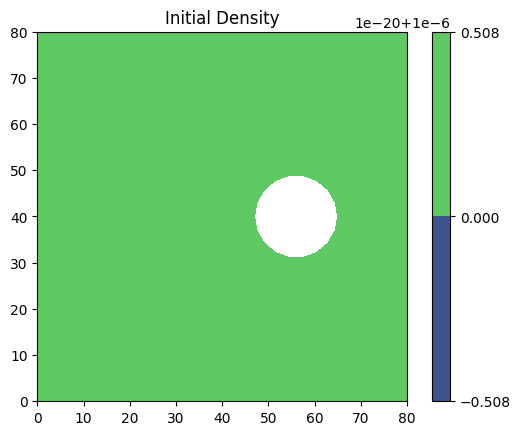

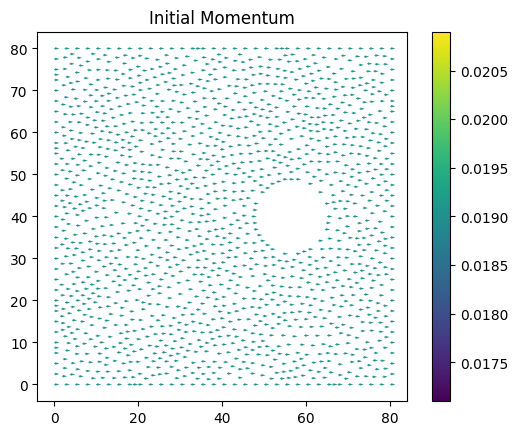

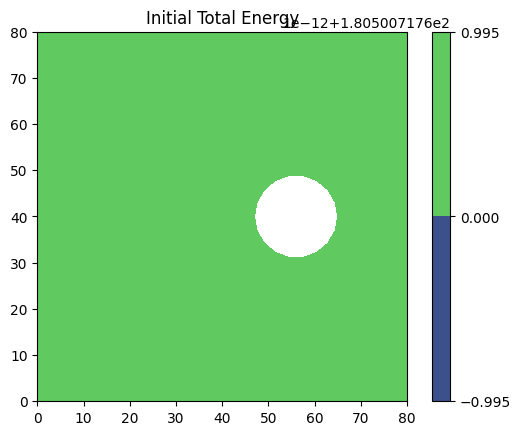

In [ ]:
!rm results-NS/*

# Problems with stability, and time update due to high velocity
def update_dt(velocity, temperature, gamma=1.4, R=287.05, cfl=0.5):
    h = mesh.hmin()
    c = np.sqrt(gamma * R * temperature)  # approximate local sound speed
    max_speed = velocity + c
    return max(cfl * h / max_speed, 5e-4)

# Initial altitude and velocity
altitude = 150000.0  # meters
velocity = 19000.0   # 19 km/s initial velocity downward
mass_object = mass_object  # kg, defined earlier
g = 9.81             # m/s²

# Initialize inflow quantities
rho_init = inflow_density(altitude)
E_init = inflow_energy(altitude, velocity)

r0.interpolate(Constant(rho_init))
m0.interpolate(Constant((rho_init * velocity, 0.0)))
E0.interpolate(Constant(E_init))

# Plot initial solution
plt.figure()
im = plot(r0, title="Initial Density")
plt.colorbar(im)

plt.figure()
im = plot(m0, title="Initial Momentum")
plt.colorbar(im)

plt.figure()
im = plot(E0, title="Initial Total Energy")
plt.colorbar(im)

################

# Time stepping (stops at around 5 km altitude)
t = float(dt)
plot_time = 0.0

while altitude > 5000.0:

  # Update inflow based on altitude and current velocity
  rho_in = inflow_density(altitude)
  E_in = inflow_energy(altitude, velocity)

  m_in_val.assign(rho_in * velocity)
  r_in_val.assign(rho_in)
  E_in_val.assign(E_in)

  # Update time step dynamically
  Temperature = inflow_temperature(altitude)
  dt.assign(update_dt(velocity, Temperature))
  current_dt = float(dt)  # store the current time step value

  # Nonlinear iterations
  for k in range(num_nnlin_iter):
      Ar = assemble(ar)
      br = assemble(Lr)
      [bc.apply(Ar, br) for bc in bcr]
      [bc.apply(r1.vector()) for bc in bcr]
      solve(Ar, r1.vector(), br, "bicgstab", "default")

      Am = assemble(am)
      bm = assemble(Lm)
      [bc.apply(Am, bm) for bc in bcm]
      [bc.apply(m1.vector()) for bc in bcm]
      solve(Am, m1.vector(), bm, "bicgstab", "default")

      AE = assemble(aE)
      bE = assemble(LE)
      [bc.apply(AE, bE) for bc in bcE]
      [bc.apply(E1.vector()) for bc in bcE]
      solve(AE, E1.vector(), bE, "bicgstab", "default")

      # Compute and store force
      F = assemble(Force)
      F_pressure = assemble(Force_pressure)
      if t > start_sample_time:
          force_array = np.append(force_array, normalization * F)
          force_array_pressure = np.append(force_array_pressure, normalization * F_pressure)
          time = np.append(time, t)

  # Update velocity using Newton's second law: F = ma => a = (mg - D)/m
  drag_force = float(F)  # from FEM
  net_force = mass_object * g - drag_force
  acceleration = net_force / mass_object
  velocity += acceleration * current_dt

  # Update altitude based on velocity
  altitude -= velocity * current_dt

  # Print out relevant info
  print(f"t = {t:.2f}s, dt = {current_dt:.4f}s, altitude = {altitude:.1f} m, velocity = {velocity:.2f} m/s, drag = {drag_force:.2f} N")

  # Output every plot interval
  if t > plot_time:
      u1 = m1 / (r1 + eps_cav)
      Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)
      c = sqrt(gamma * (gamma - 1.0) * abs(Temp))
      Mach_number = project(sqrt(inner(u1, u1)) / (c + eps_cav), Q)

      file_r << r1
      file_m << m1
      file_E << E1
      file_Mach << Mach_number

      plot_time += 1.0  # plot every 1 second

  # Prepare for next step
  r0.assign(r1)
  m0.assign(m1)
  E0.assign(E1)
  t += current_dt

# Export results
# !tar -czvf results-NS.tar.gz results-NS
# files.download('results-NS.tar.gz')


# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.